# Convexity Protection -- simple, 90-DTE, 20% OTM, TSLA-only

The team's originally-decided strategy direction: **short TSLL, long TSLA calls**, no
TSLA-vs-TSLL cost-benefit comparison, fully delta-neutral (hedge ratio = 1.0), rolled
purely on a DTE trigger. No coverage bands, no move triggers, no equity-tracking resizes
-- deliberately the simplest version of the idea, after a long stretch today where more
complex mechanisms (coverage bands, move-triggered rebalancing, equity-tracked short
resizing) mostly failed held-out testing.

This is `scripts/strategies/convexity_protection.py`'s single-bucket case, unchanged in
mechanics, with `TARGET_DTE=90` instead of 180 (90-DTE outperformed 180-DTE on the
continuous out-of-train test earlier this session) and `MONEYNESS_BUCKET="20% OTM"` only
(not the full ATM/10%/20%/spread sweep):

- **Short leg**: $1 notional TSLL, buy & hold from inception, never reset
  (`equity = 2.0 - cumprod(1+r_TSLL)`).
- **Call leg**: at each roll (held DTE < `ROLL_DTE=14`), price one TSLA 20%-OTM call
  closest to `TARGET_DTE=90` (capped at `MAX_DTE=110`), sized so its dollar delta exactly
  offsets the short's CURRENT dollar delta: `n = (TSLL_LEVER x cum_tsll) / (delta x 100 x S)`.
  As TSLL's cumulative move grows, the required hedge size grows with it automatically.
- **Frictionless**: no transaction costs, no borrow rate -- matches
  `convexity_protection.py` exactly. Turnover here is low (~1 roll per 76 days), so this
  is a reasonable simplification, not a major omission.
- **Full-period run only**, no train/test/held-out split this time (explicit choice --
  today's broader lesson about full-period fits not surviving held-out testing still
  applies in general, worth remembering if this number looks unexpectedly great).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]  # scripts/utils/ -> project root
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from data_loader import load_tsla_underlying, load_tsll, load_tsla_calls
from options_selection import select_contract, bs_delta
from metrics import summarize

%matplotlib inline
print("Imports OK")

Imports OK


## Load data

In [2]:
tsll = load_tsll()
r_tsll = tsll.set_index("Date")["Close"].pct_change().dropna()
returns = r_tsll.rename("TSLL").to_frame()

tsla_spot = load_tsla_underlying().set_index("Date")["Close"].reindex(returns.index).ffill()

tsla_calls = load_tsla_calls()
price_lookup = tsla_calls.set_index(["raw_id", "date"])["px_last"].to_dict()

print(f"{len(returns):,} trading days, {returns.index.min().date()} -> {returns.index.max().date()}")

962 trading days, 2022-08-10 -> 2026-06-10


## Config

In [3]:
TARGET_DTE = 90
ROLL_DTE = 21
MAX_DTE = 110               # 90 + 20 buffer, same convention used throughout this session
BUCKET_FALLBACK_CHAIN = ["20% OTM", "ATM"]   # try 20% OTM first; if no valid fill, fall
                                              # back to ATM (more liquid, closer to the
                                              # money) rather than ever going unhedged
TSLL_LEVER = 2.0            # TSLL nominal leverage vs TSLA -- fixed, stated leverage ratio
R_RF = 0.05                 # risk-free rate proxy (annualised)
VOL_WINDOW = 21             # days for realised-vol used in BS delta -- stated convention

r_tsla = tsla_spot.pct_change()
sigma_series = (r_tsla.rolling(VOL_WINDOW).std() * (252 ** 0.5)).ffill().bfill()

print(f"target_dte={TARGET_DTE}  roll_dte={ROLL_DTE}  max_dte={MAX_DTE}  "
      f"bucket_fallback_chain={BUCKET_FALLBACK_CHAIN}  tsll_lever={TSLL_LEVER}")
print("Back to plain calendar-only rolling (DTE trigger only) -- every band/delta-triggered")
print("early-reroll variant underperformed this today, for the reasons just discussed.")

target_dte=90  roll_dte=21  max_dte=110  bucket_fallback_chain=['20% OTM', 'ATM']  tsll_lever=2.0
Back to plain calendar-only rolling (DTE trigger only) -- every band/delta-triggered
early-reroll variant underperformed this today, for the reasons just discussed.


## `simulate` -- short $1 TSLL (fixed, never reset) + long TSLA 20%-OTM call, delta-neutral, DTE-rolled

In [4]:
def simulate(returns, calls, spot, bucket_fallback_chain, price_lookup, sigma_series, buffer=1.0):
    """Buy & hold short $1 TSLL plus a long TSLA call, rolled on a DTE trigger ONLY (plain
    calendar-only -- every early-intervention variant tried today underperformed this).
    At each roll the call is sized to `buffer` x the delta-neutral target: dollar delta =
    buffer x TSLL_LEVER x cum_tsll. buffer=1.0 is exact delta-neutral (the default all day);
    buffer>1.0 over-hedges -- spends more premium so the call absorbs more of a rally,
    trading away some average return for more consistency (less catastrophic downside).

    At each roll, tries `bucket_fallback_chain` in order (e.g. 20% OTM, then ATM) and uses
    the first bucket with a real fill (px_last>0, px_volume>0) -- never leaves the position
    unhedged if ANY bucket in the chain has a valid contract that day."""
    cum_tsll = (1 + returns["TSLL"]).cumprod()
    base_equity = 2.0 - cum_tsll

    equity = pd.Series(index=returns.index, dtype=float)
    position = None
    option_pnl = 0.0
    n_unhedged = 0
    total_hedge_cost = 0.0
    bucket_used_counts = {b: 0 for b in bucket_fallback_chain}

    def mtm_price(raw_id, strike, expiry, date, last_known):
        if date > expiry:
            return max(spot.loc[date] - strike, 0.0)
        px = price_lookup.get((raw_id, date))
        if px is not None and not pd.isna(px):
            return float(px)
        return last_known

    for d in returns.index:
        held_dte = (position["expiry"] - d).days if position is not None else -1
        need_roll = position is None or held_dte < ROLL_DTE

        if need_roll:
            if position is not None:
                px = mtm_price(position["raw_id"], position["strike"], position["expiry"], d, position["price"])
                option_pnl += position["n"] * 100 * (px - position["price"])

            row = None
            bucket_hit = None
            for bucket in bucket_fallback_chain:
                row = select_contract(calls, spot, d, bucket, TARGET_DTE, max_dte=MAX_DTE)
                if row is not None:
                    bucket_hit = bucket
                    break

            if row is not None:
                S = float(spot.loc[d])
                sigma = float(sigma_series.loc[d]) if d in sigma_series.index else 0.5
                T = (row["expiry"] - d).days / 365.25
                delta = bs_delta(S, float(row["strike"]), T, R_RF, sigma)

                short_delta = buffer * TSLL_LEVER * float(cum_tsll.loc[d])
                n = short_delta / (max(delta, 0.01) * 100 * S)
                entry = float(row["px_last"])

                position = {"raw_id": row["raw_id"], "strike": float(row["strike"]),
                            "expiry": row["expiry"], "n": n, "price": entry}
                total_hedge_cost += n * 100 * entry
                bucket_used_counts[bucket_hit] += 1
            else:
                position = None
                n_unhedged += 1
        else:
            px = mtm_price(position["raw_id"], position["strike"], position["expiry"], d, position["price"])
            option_pnl += position["n"] * 100 * (px - position["price"])
            position["price"] = px

        equity.loc[d] = base_equity.loc[d] + option_pnl

    return equity, n_unhedged, total_hedge_cost, bucket_used_counts

## Windows -- same dates used throughout this session, plus full period

In [5]:
TRAIN_START = pd.Timestamp("2022-09-09")
TRAIN_END   = pd.Timestamp("2023-01-03")
TEST_A_START = pd.Timestamp("2024-12-17")   # decline
TEST_A_END   = pd.Timestamp("2025-04-08")
TEST_B_START = pd.Timestamp("2025-04-08")   # rally
TEST_B_END   = pd.Timestamp("2025-12-16")

idx = returns.index
WINDOWS = {
    "train": idx[(idx >= TRAIN_START) & (idx <= TRAIN_END)],
    "testA (decline)": idx[(idx >= TEST_A_START) & (idx <= TEST_A_END)],
    "testB (rally)": idx[(idx >= TEST_B_START) & (idx <= TEST_B_END)],
    "continuous out-of-train": idx[idx > TRAIN_END],
    "full period": idx,
}

BUFFERS = [0.6, 0.8, 1.0, 1.25, 1.5, 2.0]   # 1.0 = exact delta-neutral; <1.0 = under-hedged

curves = {}
rows = []
for buffer in BUFFERS:
    curves[buffer] = {}
    for win_name, win_dates in WINDOWS.items():
        win_returns = returns.loc[win_dates]
        eq, n_unhedged, hedge_cost, bucket_used_counts = simulate(
            win_returns, tsla_calls, tsla_spot, BUCKET_FALLBACK_CHAIN, price_lookup, sigma_series, buffer=buffer)
        eq = eq / eq.iloc[0]
        curves[buffer][win_name] = eq
        row = summarize(eq, eq.pct_change().dropna(), f"buffer={buffer}")
        row["window"] = win_name
        row["Unhedged Days"] = n_unhedged
        row["Total Hedge Cost $"] = round(hedge_cost, 4)
        rows.append(row)

results_df = pd.DataFrame(rows)[["Strategy", "window", "CAGR", "Ann. Vol", "Sharpe", "Max DD", "Calmar",
                                  "Unhedged Days", "Total Hedge Cost $"]]
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
results_df

,Strategy,window,CAGR,Ann. Vol,Sharpe,Max DD,Calmar,Unhedged Days,Total Hedge Cost $
0,buffer=0.6,train,2.516910,0.377284,3.570573,-0.084822,29.672789,0,0.4686
1,buffer=0.6,testA (decline),2.984751,0.399891,3.767855,-0.088291,33.805894,0,0.4117
2,buffer=0.6,testB (rally),-0.551737,1.271387,-0.010075,-0.580248,-0.950864,0,1.5179
3,buffer=0.6,continuous out-of-train,0.091532,14.417714,-0.763582,-1.115237,0.082074,0,9.8968
4,buffer=0.6,full period,0.160260,0.277703,0.676167,-0.318021,0.503929,0,3.2537
5,buffer=0.8,train,1.612195,0.372791,2.797688,-0.092619,17.406796,0,0.6248
6,buffer=0.8,testA (decline),1.884176,0.351990,3.279291,-0.089192,21.125029,0,0.5489
7,buffer=0.8,testB (rally),0.127281,1.205540,0.673837,-0.508193,0.250458,0,2.0239
8,buffer=0.8,continuous out-of-train,0.211732,1.174536,0.751116,-0.765107,0.276736,0,13.1957
9,buffer=0.8,full period,0.170404,0.339174,0.635630,-0.501025,0.340110,0,4.3383


## Equity curves, one panel per window, all buffers overlaid

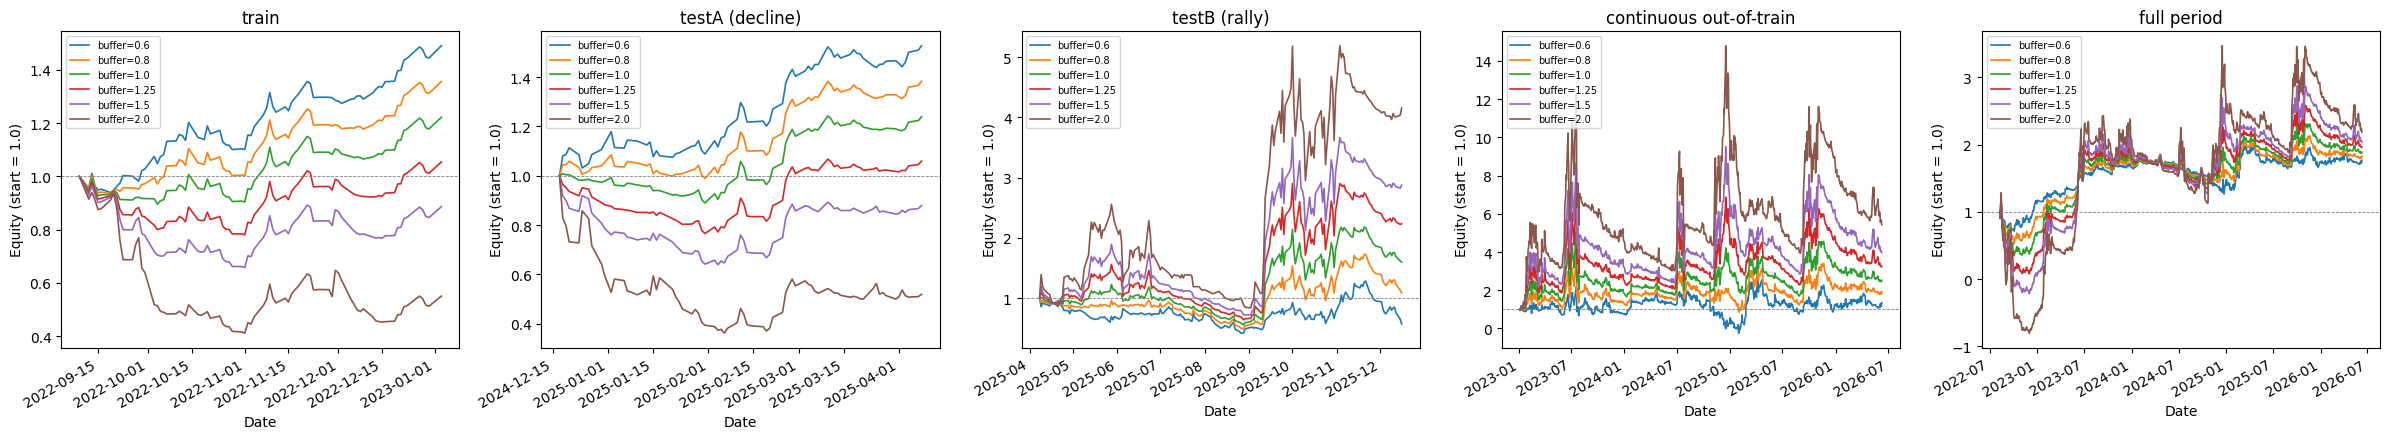

In [6]:
fig, axes = plt.subplots(1, len(WINDOWS), figsize=(24, 4.5))
for ax, win_name in zip(axes, WINDOWS.keys()):
    for buffer in BUFFERS:
        curves[buffer][win_name].plot(ax=ax, label=f"buffer={buffer}", linewidth=1.2)
    ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.6)
    ax.set_title(win_name)
    ax.set_ylabel("Equity (start = 1.0)")
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

## Sanity checks

In [7]:
for buffer, per_window in curves.items():
    for win_name, eq in per_window.items():
        assert eq.isna().sum() == 0, f"buffer={buffer} / {win_name}: equity has NaNs"
        assert eq.min() > -10.0, f"buffer={buffer} / {win_name}: equity implausible ({eq.min():.2f})"

print("Sanity checks passed.")
print("\nFull comparison:")
print(results_df.to_string(index=False))

Sanity checks passed.

Full comparison:
   Strategy                  window      CAGR  Ann. Vol    Sharpe    Max DD    Calmar  Unhedged Days  Total Hedge Cost $
 buffer=0.6                   train  2.516910  0.377284  3.570573 -0.084822 29.672789              0              0.4686
 buffer=0.6         testA (decline)  2.984751  0.399891  3.767855 -0.088291 33.805894              0              0.4117
 buffer=0.6           testB (rally) -0.551737  1.271387 -0.010075 -0.580248 -0.950864              0              1.5179
 buffer=0.6 continuous out-of-train  0.091532 14.417714 -0.763582 -1.115237  0.082074              0              9.8968
 buffer=0.6             full period  0.160260  0.277703  0.676167 -0.318021  0.503929              0              3.2537
 buffer=0.8                   train  1.612195  0.372791  2.797688 -0.092619 17.406796              0              0.6248
 buffer=0.8         testA (decline)  1.884176  0.351990  3.279291 -0.089192 21.125029              0             

## Joint grid: moneyness x target_dte x buffer

Testing whether moneyness or target_dte, combined with buffer, break the seesaw found
above (buffer<1 helps decline windows and hurts the rally window; buffer>1 does the
reverse) -- or whether the seesaw is structural regardless of these other two levers.

`ROLL_DTE` stays fixed at 21 for every `target_dte` in this grid (already validated as the
winner at target_dte=90 earlier this session; not re-swept here to keep the grid tractable
-- a real limitation, noted rather than silently assumed away). Each moneyness bucket
falls back to ATM if its primary bucket has no valid fill that day (same liquidity
safeguard as before); ATM's own "chain" is just itself.

Ranking: worst-case Sharpe across the four REAL windows (train, testA, testB, continuous
out-of-train) -- excluding "full period" from the ranking criterion, since it's already
been shown to mask the rally-window risk that continuous out-of-train correctly exposes.

In [8]:
def simulate_grid(returns, calls, spot, bucket_fallback_chain, price_lookup, sigma_series,
                   target_dte, roll_dte, max_dte, buffer):
    """Same mechanics as `simulate`, parametrized over target_dte/roll_dte/max_dte too
    (the plain `simulate` above hardcodes these as module-level constants)."""
    cum_tsll = (1 + returns["TSLL"]).cumprod()
    base_equity = 2.0 - cum_tsll

    equity = pd.Series(index=returns.index, dtype=float)
    position = None
    option_pnl = 0.0
    n_unhedged = 0

    def mtm_price(raw_id, strike, expiry, date, last_known):
        if date > expiry:
            return max(spot.loc[date] - strike, 0.0)
        px = price_lookup.get((raw_id, date))
        if px is not None and not pd.isna(px):
            return float(px)
        return last_known

    for d in returns.index:
        held_dte = (position["expiry"] - d).days if position is not None else -1
        need_roll = position is None or held_dte < roll_dte

        if need_roll:
            if position is not None:
                px = mtm_price(position["raw_id"], position["strike"], position["expiry"], d, position["price"])
                option_pnl += position["n"] * 100 * (px - position["price"])

            row = None
            for bucket in bucket_fallback_chain:
                row = select_contract(calls, spot, d, bucket, target_dte, max_dte=max_dte)
                if row is not None:
                    break

            if row is not None:
                S = float(spot.loc[d])
                sigma = float(sigma_series.loc[d]) if d in sigma_series.index else 0.5
                T = (row["expiry"] - d).days / 365.25
                delta = bs_delta(S, float(row["strike"]), T, R_RF, sigma)

                short_delta = buffer * TSLL_LEVER * float(cum_tsll.loc[d])
                n = short_delta / (max(delta, 0.01) * 100 * S)
                entry = float(row["px_last"])

                position = {"raw_id": row["raw_id"], "strike": float(row["strike"]),
                            "expiry": row["expiry"], "n": n, "price": entry}
            else:
                position = None
                n_unhedged += 1
        else:
            px = mtm_price(position["raw_id"], position["strike"], position["expiry"], d, position["price"])
            option_pnl += position["n"] * 100 * (px - position["price"])
            position["price"] = px

        equity.loc[d] = base_equity.loc[d] + option_pnl

    return equity, n_unhedged


MONEYNESS_OPTIONS = ["ATM", "10% OTM", "20% OTM"]
DTE_OPTIONS = [60, 90, 120]
GRID_BUFFERS = [0.6, 0.8, 1.0, 1.25, 1.5]
REAL_WINDOWS = ["train", "testA (decline)", "testB (rally)", "continuous out-of-train"]

grid_rows = []
total_combos = len(MONEYNESS_OPTIONS) * len(DTE_OPTIONS) * len(GRID_BUFFERS)
i = 0
for bucket in MONEYNESS_OPTIONS:
    chain = [bucket] if bucket == "ATM" else [bucket, "ATM"]
    for dte in DTE_OPTIONS:
        max_dte_grid = dte + 20
        for buffer in GRID_BUFFERS:
            i += 1
            per_window = {}
            for win_name in REAL_WINDOWS:
                win_returns = returns.loc[WINDOWS[win_name]]
                eq, n_unhedged = simulate_grid(win_returns, tsla_calls, tsla_spot, chain,
                                               price_lookup, sigma_series, dte, ROLL_DTE, max_dte_grid, buffer)
                eq = eq / eq.iloc[0]
                s = summarize(eq, eq.pct_change().dropna(), "")
                per_window[win_name] = s
            worst_sharpe = min(per_window[w]["Sharpe"] for w in REAL_WINDOWS)
            worst_maxdd = min(per_window[w]["Max DD"] for w in REAL_WINDOWS)
            grid_rows.append({
                "bucket": bucket, "target_dte": dte, "buffer": buffer,
                "worst_sharpe": worst_sharpe, "worst_maxdd": worst_maxdd,
                **{f"{w}_sharpe": per_window[w]["Sharpe"] for w in REAL_WINDOWS},
                **{f"{w}_maxdd": per_window[w]["Max DD"] for w in REAL_WINDOWS},
            })

grid_df = pd.DataFrame(grid_rows)
print(f"Ran {i}/{total_combos} combos.")
grid_df.sort_values("worst_sharpe", ascending=False).head(10)

Ran 45/45 combos.


,bucket,target_dte,buffer,worst_sharpe,worst_maxdd,train_sharpe,testA (decline)_sharpe,testB (rally)_sharpe,continuous out-of-train_sharpe,train_maxdd,testA (decline)_maxdd,testB (rally)_maxdd,continuous out-of-train_maxdd
32,20% OTM,60,1.00,1.093964,-0.680041,1.624238,1.715410,1.244356,1.093964,-0.103550,-0.128330,-0.680041,-0.427385
31,20% OTM,60,0.80,0.953082,-0.645487,2.592280,2.739278,0.953082,0.998000,-0.094383,-0.105537,-0.645487,-0.497301
37,20% OTM,90,1.00,0.788054,-0.667388,1.831410,2.309769,1.128453,0.788054,-0.104694,-0.118248,-0.545821,-0.667388
12,ATM,120,1.00,0.784812,-0.534151,2.490643,2.082779,0.784812,0.979313,-0.151014,-0.114867,-0.330724,-0.534151
27,10% OTM,120,1.00,0.679946,-0.584934,2.098466,1.818896,0.679946,0.951423,-0.098206,-0.164041,-0.282520,-0.584934
36,20% OTM,90,0.80,0.673837,-0.765107,2.797688,3.279291,0.673837,0.751116,-0.092619,-0.089192,-0.508193,-0.765107
43,20% OTM,120,1.25,0.673199,-0.646827,1.230813,0.673199,1.050682,0.949601,-0.258370,-0.233439,-0.365829,-0.646827
38,20% OTM,90,1.25,0.595615,-0.697583,0.595615,0.688345,1.472069,0.853178,-0.219375,-0.234473,-0.589425,-0.697583
13,ATM,120,1.25,0.514148,-0.589710,1.500858,0.514148,1.190598,1.069953,-0.273569,-0.233439,-0.381960,-0.589710
30,20% OTM,60,0.60,0.510982,-0.660108,3.390296,3.394270,0.510982,0.833160,-0.086571,-0.098168,-0.660108,-0.650022


In [9]:
assert grid_df.isna().sum().sum() == 0, "grid has NaNs somewhere"

best = grid_df.sort_values("worst_sharpe", ascending=False).iloc[0]
print("Best combo by worst-case Sharpe across train/testA/testB/continuous:")
print(best.to_string())
print()
print(f"\nDoes any combo have a positive worst-case Sharpe? "
      f"{'YES' if (grid_df['worst_sharpe'] > 0).any() else 'NO'} "
      f"({(grid_df['worst_sharpe'] > 0).sum()} / {len(grid_df)} combos)")
print(f"Does any combo have worst-case MaxDD better than -50%? "
      f"{'YES' if (grid_df['worst_maxdd'] > -0.50).any() else 'NO'} "
      f"({(grid_df['worst_maxdd'] > -0.50).sum()} / {len(grid_df)} combos)")

Best combo by worst-case Sharpe across train/testA/testB/continuous:
bucket                             20% OTM
target_dte                              60
buffer                                 1.0
worst_sharpe                      1.093964
worst_maxdd                      -0.680041
train_sharpe                      1.624238
testA (decline)_sharpe             1.71541
testB (rally)_sharpe              1.244356
continuous out-of-train_sharpe    1.093964
train_maxdd                       -0.10355
testA (decline)_maxdd             -0.12833
testB (rally)_maxdd              -0.680041
continuous out-of-train_maxdd    -0.427385


Does any combo have a positive worst-case Sharpe? YES (21 / 45 combos)
Does any combo have worst-case MaxDD better than -50%? YES (1 / 45 combos)


## Grid heatmaps -- worst-case Sharpe and worst-case MaxDD, one panel per moneyness bucket

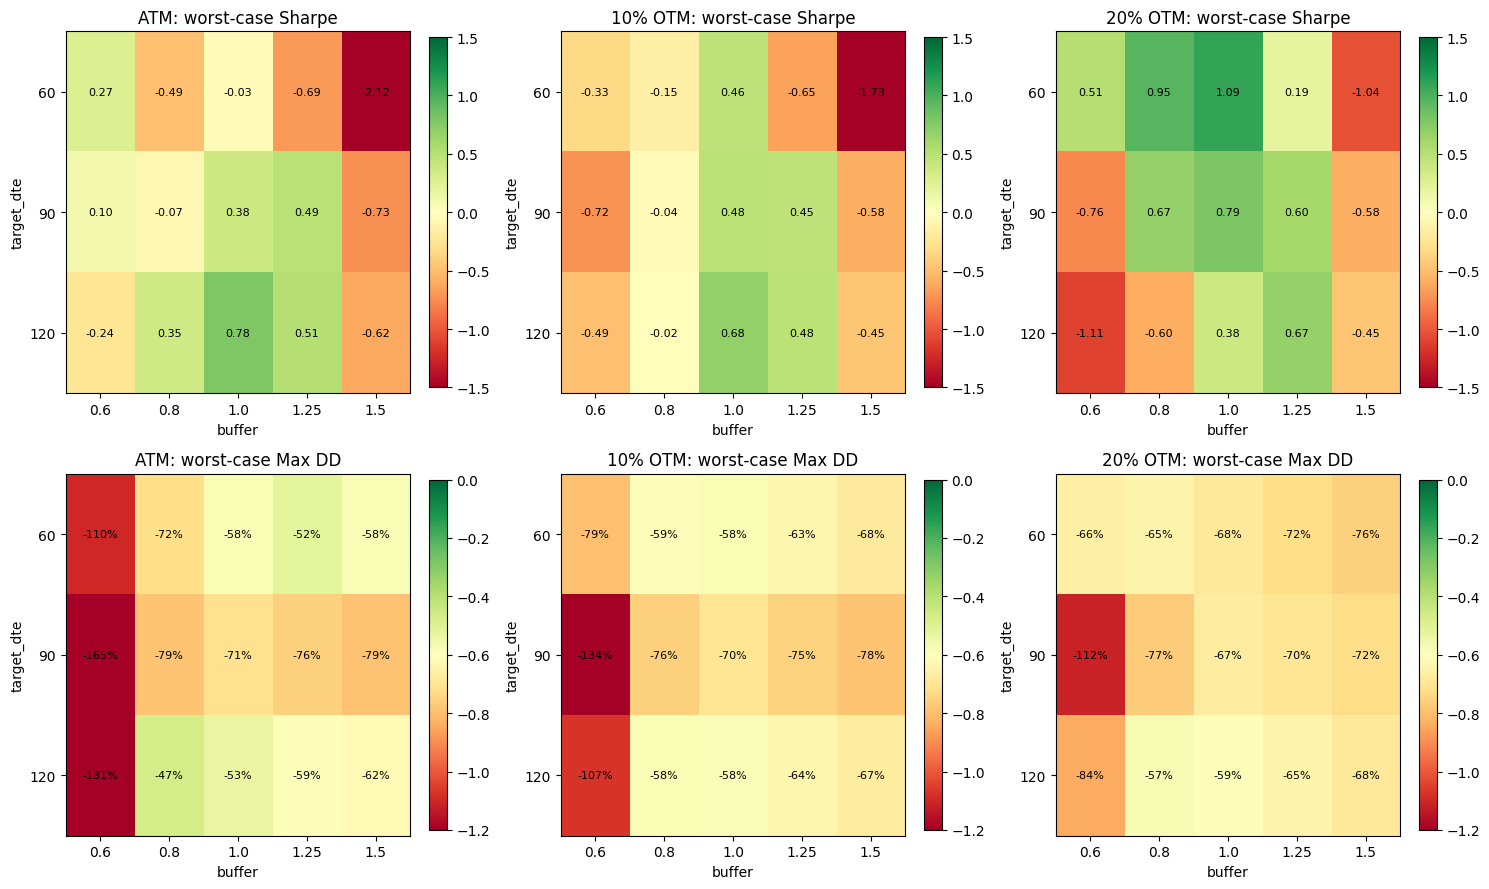

In [10]:
import numpy as np

fig, axes = plt.subplots(2, len(MONEYNESS_OPTIONS), figsize=(15, 9))

for col, bucket in enumerate(MONEYNESS_OPTIONS):
    sub = grid_df[grid_df["bucket"] == bucket]

    pivot_sharpe = sub.pivot(index="target_dte", columns="buffer", values="worst_sharpe")
    ax = axes[0, col]
    im = ax.imshow(pivot_sharpe.values, aspect="auto", cmap="RdYlGn", vmin=-1.5, vmax=1.5)
    ax.set_xticks(range(len(pivot_sharpe.columns)))
    ax.set_xticklabels(pivot_sharpe.columns)
    ax.set_yticks(range(len(pivot_sharpe.index)))
    ax.set_yticklabels(pivot_sharpe.index)
    ax.set_xlabel("buffer")
    ax.set_ylabel("target_dte")
    ax.set_title(f"{bucket}: worst-case Sharpe")
    for r in range(pivot_sharpe.shape[0]):
        for c in range(pivot_sharpe.shape[1]):
            ax.text(c, r, f"{pivot_sharpe.values[r, c]:.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)

    pivot_maxdd = sub.pivot(index="target_dte", columns="buffer", values="worst_maxdd")
    ax = axes[1, col]
    im = ax.imshow(pivot_maxdd.values, aspect="auto", cmap="RdYlGn", vmin=-1.2, vmax=0.0)
    ax.set_xticks(range(len(pivot_maxdd.columns)))
    ax.set_xticklabels(pivot_maxdd.columns)
    ax.set_yticks(range(len(pivot_maxdd.index)))
    ax.set_yticklabels(pivot_maxdd.index)
    ax.set_xlabel("buffer")
    ax.set_ylabel("target_dte")
    ax.set_title(f"{bucket}: worst-case Max DD")
    for r in range(pivot_maxdd.shape[0]):
        for c in range(pivot_maxdd.shape[1]):
            ax.text(c, r, f"{pivot_maxdd.values[r, c]:.0%}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)

fig.tight_layout()
plt.show()

## Basket hedge -- multiple strikes held simultaneously, rolled together

Per Nitesh's suggestion: instead of concentrating the entire target dollar-delta into ONE
strike, split it across a SIMULTANEOUS basket of strikes (ATM, 10% OTM, 20% OTM -- equal
weight, 1/3 each), all struck near the same `target_dte` and rolled together on a single
shared trigger. This is deliberately different from `ensemble_contracts_sandbox.ipynb`
(dropped earlier today): that ran three INDEPENDENT single-option slots, each on its own
DTE/roll schedule -- effectively three parallel copies of the same fragile single-option
strategy. This basket is genuinely one combined position: same roll cadence for every leg,
tested to see whether averaging delta across strikes smooths the "delta collapse" problem
found earlier (a single deep-OTM contract's delta collapsing toward zero, forcing runaway
correction) -- since only part of the basket would ever be that far from the money at once.

Roll trigger: the EARLIEST-expiring leg's DTE (so no leg is ever left with less than
`ROLL_DTE` days remaining) -- conservative, keeps all three legs synchronized.

In [11]:
def simulate_basket(returns, calls, spot, basket_buckets, price_lookup, sigma_series,
                     target_dte, roll_dte, max_dte, buffer=1.0):
    """Short $1 TSLL + a SIMULTANEOUS basket of TSLA calls (equal weight across
    `basket_buckets`), all rolled together (single shared trigger = earliest-expiring
    leg's DTE). Each leg's own bucket is tried first; falls back to ATM for that leg
    specifically if its own bucket has no valid fill that day."""
    cum_tsll = (1 + returns["TSLL"]).cumprod()
    base_equity = 2.0 - cum_tsll

    equity = pd.Series(index=returns.index, dtype=float)
    positions = {b: None for b in basket_buckets}
    option_pnl = 0.0
    n_leg_misses = 0

    def mtm_price(raw_id, strike, expiry, date, last_known):
        if date > expiry:
            return max(spot.loc[date] - strike, 0.0)
        px = price_lookup.get((raw_id, date))
        if px is not None and not pd.isna(px):
            return float(px)
        return last_known

    for d in returns.index:
        held_dtes = [(positions[b]["expiry"] - d).days if positions[b] is not None else -1
                     for b in basket_buckets]
        need_roll = any(positions[b] is None for b in basket_buckets) or min(held_dtes) < roll_dte

        if need_roll:
            for b in basket_buckets:
                pos = positions[b]
                if pos is not None:
                    px = mtm_price(pos["raw_id"], pos["strike"], pos["expiry"], d, pos["price"])
                    option_pnl += pos["n"] * 100 * (px - pos["price"])

            target_per_leg = buffer * TSLL_LEVER * float(cum_tsll.loc[d]) / len(basket_buckets)
            new_positions = {}
            for b in basket_buckets:
                row = select_contract(calls, spot, d, b, target_dte, max_dte=max_dte)
                if row is None:
                    row = select_contract(calls, spot, d, "ATM", target_dte, max_dte=max_dte)
                if row is not None:
                    S = float(spot.loc[d])
                    sigma = float(sigma_series.loc[d]) if d in sigma_series.index else 0.5
                    T = (row["expiry"] - d).days / 365.25
                    delta = bs_delta(S, float(row["strike"]), T, R_RF, sigma)
                    n = target_per_leg / (max(delta, 0.01) * 100 * S)
                    entry = float(row["px_last"])
                    new_positions[b] = {"raw_id": row["raw_id"], "strike": float(row["strike"]),
                                         "expiry": row["expiry"], "n": n, "price": entry}
                else:
                    new_positions[b] = None
                    n_leg_misses += 1
            positions = new_positions
        else:
            for b in basket_buckets:
                pos = positions[b]
                if pos is not None:
                    px = mtm_price(pos["raw_id"], pos["strike"], pos["expiry"], d, pos["price"])
                    option_pnl += pos["n"] * 100 * (px - pos["price"])
                    pos["price"] = px

        equity.loc[d] = base_equity.loc[d] + option_pnl

    return equity, n_leg_misses


BASKET_BUCKETS = ["ATM", "10% OTM", "20% OTM"]

curves_basket = {}
rows_basket = []
for win_name, win_dates in WINDOWS.items():
    win_returns = returns.loc[win_dates]
    eq, n_leg_misses = simulate_basket(win_returns, tsla_calls, tsla_spot, BASKET_BUCKETS,
                                       price_lookup, sigma_series, TARGET_DTE, ROLL_DTE, MAX_DTE, buffer=1.0)
    eq = eq / eq.iloc[0]
    curves_basket[win_name] = eq
    row = summarize(eq, eq.pct_change().dropna(), "Basket (ATM+10%OTM+20%OTM, equal weight)")
    row["window"] = win_name
    row["Leg misses"] = n_leg_misses
    rows_basket.append(row)

results_basket_df = pd.DataFrame(rows_basket)[["Strategy", "window", "CAGR", "Ann. Vol", "Sharpe", "Max DD",
                                                "Calmar", "Leg misses"]]
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
results_basket_df

,Strategy,window,CAGR,Ann. Vol,Sharpe,Max DD,Calmar,Leg misses
0,"Basket (ATM+10%OTM+20%OTM, equal weight)",train,0.886546,0.382161,1.872465,-0.132749,6.678353,0
1,"Basket (ATM+10%OTM+20%OTM, equal weight)",testA (decline),0.952030,0.345494,2.165447,-0.131597,7.234448,0
2,"Basket (ATM+10%OTM+20%OTM, equal weight)",testB (rally),0.399201,0.787407,0.801652,-0.364812,1.094267,0
3,"Basket (ATM+10%OTM+20%OTM, equal weight)",continuous out-of-train,0.127684,0.836981,0.561653,-0.662622,0.192695,0
4,"Basket (ATM+10%OTM+20%OTM, equal weight)",full period,0.146232,0.283622,0.625382,-0.443488,0.329731,0


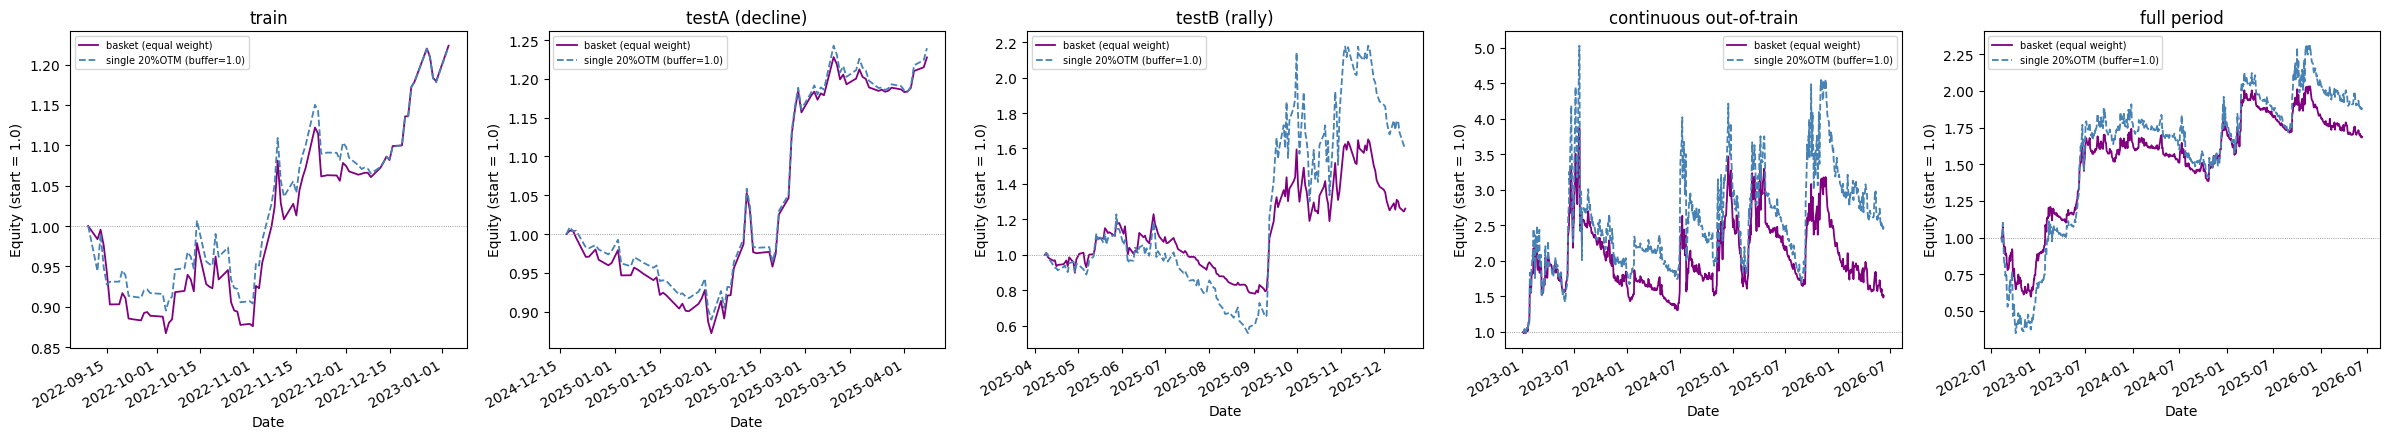

Sanity checks passed.

Basket vs. single-position baseline (buffer=1.0), worst-case across train/testA/testB/continuous:
  Basket:  worst Sharpe=0.56  worst MaxDD=-66.3%
  Single:  worst Sharpe=0.79  worst MaxDD=-66.7%

Full comparison:
                                Strategy                  window     CAGR  Ann. Vol   Sharpe    Max DD   Calmar  Leg misses
Basket (ATM+10%OTM+20%OTM, equal weight)                   train 0.886546  0.382161 1.872465 -0.132749 6.678353           0
Basket (ATM+10%OTM+20%OTM, equal weight)         testA (decline) 0.952030  0.345494 2.165447 -0.131597 7.234448           0
Basket (ATM+10%OTM+20%OTM, equal weight)           testB (rally) 0.399201  0.787407 0.801652 -0.364812 1.094267           0
Basket (ATM+10%OTM+20%OTM, equal weight) continuous out-of-train 0.127684  0.836981 0.561653 -0.662622 0.192695           0
Basket (ATM+10%OTM+20%OTM, equal weight)             full period 0.146232  0.283622 0.625382 -0.443488 0.329731           0


In [12]:
fig, axes = plt.subplots(1, len(WINDOWS), figsize=(24, 4.5))
for ax, win_name in zip(axes, WINDOWS.keys()):
    curves_basket[win_name].plot(ax=ax, label="basket (equal weight)", color="purple", linewidth=1.3)
    curves[1.0][win_name].plot(ax=ax, label="single 20%OTM (buffer=1.0)", color="steelblue", linewidth=1.3, linestyle="--")
    ax.axhline(1.0, color="grey", linestyle=":", linewidth=0.6)
    ax.set_title(win_name)
    ax.set_ylabel("Equity (start = 1.0)")
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

for win_name, eq in curves_basket.items():
    assert eq.isna().sum() == 0, f"{win_name}: basket equity has NaNs"
    assert eq.min() > -10.0, f"{win_name}: basket equity implausible ({eq.min():.2f})"

print("Sanity checks passed.")
print("\nBasket vs. single-position baseline (buffer=1.0), worst-case across train/testA/testB/continuous:")
basket_worst_sharpe = results_basket_df[results_basket_df["window"] != "full period"]["Sharpe"].min()
basket_worst_maxdd = results_basket_df[results_basket_df["window"] != "full period"]["Max DD"].min()
single_worst_sharpe = results_df[(results_df["Strategy"] == "buffer=1.0") & (results_df["window"] != "full period")]["Sharpe"].min()
single_worst_maxdd = results_df[(results_df["Strategy"] == "buffer=1.0") & (results_df["window"] != "full period")]["Max DD"].min()
print(f"  Basket:  worst Sharpe={basket_worst_sharpe:.2f}  worst MaxDD={basket_worst_maxdd:.1%}")
print(f"  Single:  worst Sharpe={single_worst_sharpe:.2f}  worst MaxDD={single_worst_maxdd:.1%}")
print("\nFull comparison:")
print(results_basket_df.to_string(index=False))